In [2]:
!pip install ipympl

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   --------------------- ---------------- 524.3/914.9 kB 441.3 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/914.9 kB 441.3 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/914.9 kB 441.3 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 441.3 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 441.3 kB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 439.9 kB/s  0:00:02
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------------

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor

# Enable interactive plotting
%matplotlib widget

# Check for JSON files in the directory to help locate the map file
print("JSON files in current directory:")
json_files = [f for f in os.listdir('.') if f.endswith('.json')]
print(json_files if json_files else "No JSON files found. (Will use dummy data for demo)")

# Define Field Dimensions (from FRC 2026 Manual)
# 54' 3" = 16.5354 meters
# 26' 3" = 8.001 meters
FIELD_LENGTH = 16.5354
FIELD_WIDTH = 8.001

JSON files in current directory:
['2025-rebuilt-welded.json', '2025-reefscape-welded.json', '2026-rebuilt-welded.json']


In [2]:
def load_field_data(filename):
    """
    Loads AprilTags from a WPILib-style JSON file.
    Returns a list of tags (dicts with 'ID' and 'pose').
    """
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as f:
                data = json.load(f)
                # WPILib JSON usually has a "tags" key and optionally "field" dimensions
                return data.get('tags', [])
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            return []
    else:
        print(f"File '{filename}' not found. Generating sample FRC 2026 tag locations.")
        # Sample data approximating REBUILT field elements
        return [
            # Blue Alliance Wall (Origin side)
            {"ID": 1, "pose": {"translation": {"x": 0.0, "y": 4.0, "z": 0.88}}},
            {"ID": 2, "pose": {"translation": {"x": 0.0, "y": 6.0, "z": 0.88}}},
            # Hub (Center Field approx)
            {"ID": 21, "pose": {"translation": {"x": FIELD_LENGTH/2, "y": FIELD_WIDTH/2, "z": 1.1}}},
            # Red Alliance Wall (Far side)
            {"ID": 15, "pose": {"translation": {"x": FIELD_LENGTH, "y": 4.0, "z": 0.88}}},
        ]

# Specify your JSON filename here (e.g., '2026-apriltag.json')
# If you uploaded a file, make sure the name matches.
json_filename = '2025-rebuilt-welded.json' 
tags = load_field_data(json_filename)
print(f"Loaded {len(tags)} AprilTags.")

Loaded 32 AprilTags.


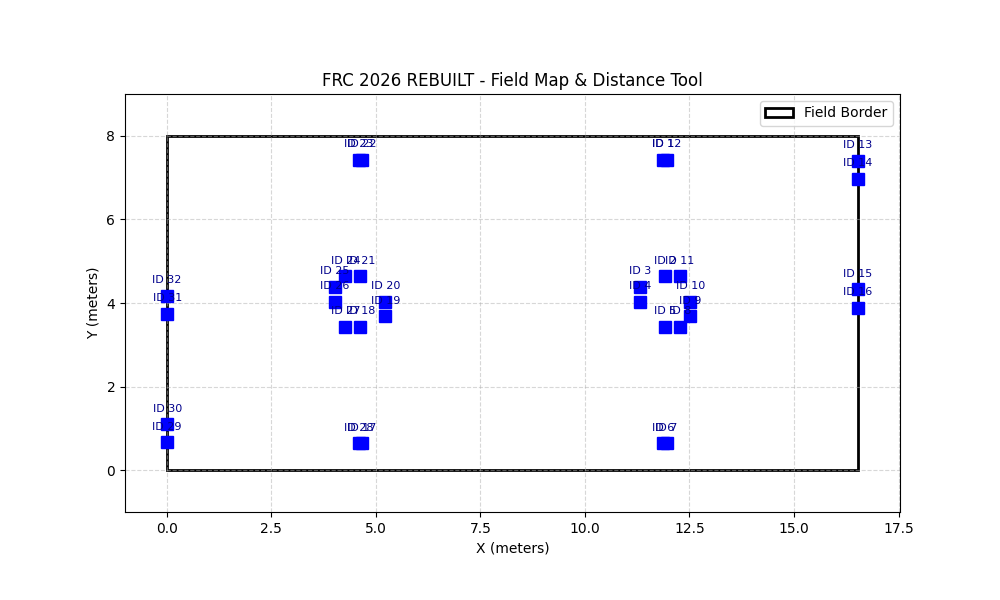

In [3]:
class InteractiveFieldMap:
    def __init__(self, tags, length, width):
        self.tags = tags
        self.length = length
        self.width = width
        self.clicks = []
        
        # Create Figure and Axes
        self.fig, self.ax = plt.subplots(figsize=(10, 6))
        self.setup_field()
        
        # Initialize event listener
        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
        
    def setup_field(self):
        self.ax.set_title("FRC 2026 REBUILT - Field Map & Distance Tool")
        self.ax.set_xlabel("X (meters)")
        self.ax.set_ylabel("Y (meters)")
        self.ax.set_aspect('equal')
        self.ax.set_xlim(-1, self.length + 1)
        self.ax.set_ylim(-1, self.width + 1)
        self.ax.grid(True, linestyle='--', alpha=0.5)
        
        # Draw Field Boundary
        boundary = plt.Rectangle((0, 0), self.length, self.width, 
                                 fill=False, edgecolor='black', linewidth=2, label='Field Border')
        self.ax.add_patch(boundary)
        
        # Plot AprilTags
        for tag in self.tags:
            tid = tag['ID']
            # Handle standard WPILib JSON structure
            if 'pose' in tag and 'translation' in tag['pose']:
                tx = tag['pose']['translation']['x']
                ty = tag['pose']['translation']['y']
            else:
                continue # Skip invalid format
            
            self.ax.plot(tx, ty, 's', color='blue', markersize=8)
            self.ax.text(tx, ty + 0.3, f"ID {tid}", ha='center', fontsize=8, color='darkblue')

        self.ax.legend(loc='upper right')

    def on_click(self, event):
        # Ignore clicks outside the axes
        if event.inaxes != self.ax:
            return

        # Add click location
        self.clicks.append((event.xdata, event.ydata))
        
        # Visual feedback for click
        if len(self.clicks) == 1:
            # First point (Start)
            self.ax.plot(event.xdata, event.ydata, 'go', markersize=6, label='Start')
            self.ax.text(event.xdata, event.ydata + 0.2, "Pt 1", color='green')
            
        elif len(self.clicks) == 2:
            # Second point (End) - Calculate Distance
            p1 = np.array(self.clicks[0])
            p2 = np.array(self.clicks[1])
            dist = np.linalg.norm(p2 - p1)
            
            # Plot second point and line
            self.ax.plot(event.xdata, event.ydata, 'ro', markersize=6, label='End')
            self.ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', linewidth=1.5)
            
            # Display distance
            mid_x, mid_y = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
            self.ax.text(mid_x, mid_y, f"{dist:.3f} m", color='red', fontweight='bold', 
                         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))
            
        else:
            # Third click - Reset
            self.clicks = []
            # Clear plotted lines/points (keeping the field map)
            # Simplest way is to clear and redraw field, or remove specific artists.
            # For simplicity, we just clear and re-setup here:
            self.ax.cla()
            self.setup_field()
            
        self.fig.canvas.draw()

# Instantiate the map
field_map = InteractiveFieldMap(tags, FIELD_LENGTH, FIELD_WIDTH)
plt.show()